# Milestone 2 - Data Pipeline and MLP Networks

**Dataset / task:** same as Milestone 1 - the SMS Spam Collection dataset, binary text classification (ham vs. spam).

This notebook builds a reusable data pipeline and a flexible MLP class (defined in the cells below), then:
1. builds a shallow MLP (2 hidden layers) and a deep MLP (5 hidden layers),
2. compares 3 loss functions x 3 optimizers (9 combinations) on the shallow network,
3. tunes the learning rate for the best combination,
4. trains the deep network with the best settings found, and
5. compares the two networks on the untouched test set.

## Setup
Libraries we need: pandas to load the CSV, scikit-learn for TF-IDF and splitting,
PyTorch for the tensors/DataLoader we'll build the network on.

In [1]:
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

## Load the data
- Load the SMS messages, keep only the label and message columns, and drop exact
- duplicate messages so the same message can't end up in two different splits later.
- Print one ham and one spam example just to confirm the data loaded correctly.

In [2]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "message"]
df = df.drop_duplicates(subset="message").reset_index(drop=True)

for lab in ["ham", "spam"]:
    print(lab, "->", df[df["label"] == lab]["message"].iloc[0])

ham -> Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
spam -> Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


## Encode labels and split the data
Turn the text labels into numbers (ham=0, spam=1), since the network needs numeric
targets. Then split into train/val/test (64% / 16% / 20% overall) with `stratify`
so every split keeps the same ~13% spam ratio. `random_state=42` just makes the
split reproducible so we get the same split every time we rerun this.

In [3]:
y = (df["label"] == "spam").astype(int).values
X_text = df["message"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42)
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(len(X_train_text), len(X_val_text), len(X_test_text))

3308 827 1034


## Turn messages into numbers (TF-IDF)
Convert each message into a vector of 3000 numbers based on word importance.
The vectorizer is fit (learns which words matter) on the training messages
only, then just applied to val/test — so no information from val/test
leaks into how the features are built.

In [4]:
vectorizer = TfidfVectorizer(max_features=3000)
X_train = vectorizer.fit_transform(X_train_text).toarray().astype("float32")
X_val = vectorizer.transform(X_val_text).toarray().astype("float32")
X_test = vectorizer.transform(X_test_text).toarray().astype("float32")

print(X_train.shape, X_val.shape, X_test.shape)

(3308, 3000) (827, 3000) (1034, 3000)


In [5]:
def to_loader(X, y, shuffle):
    dataset = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(dataset, batch_size=32, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader = to_loader(X_val, y_val, shuffle=False)
test_loader = to_loader(X_test, y_test, shuffle=False)

print("batches per epoch (train):", len(train_loader))

batches per epoch (train): 104


## Build the MLP
One flexible class: pass it a list of hidden-layer sizes and it builds that
network **Neuron counts:** shallow = 128 → 64, deep = 256 → 128 → 64 → 32 → 16. Both
start wide (close to the 3000-dimensional TF-IDF input) and taper down toward
the 2-class output — a standard "funnel" shape for MLPs. ReLU activation between layers (standard choice, cheap, avoids
vanishing gradients). The output layer has 2 numbers — one score per class
(ham/spam) — with no activation on it, because the loss function we'll use
later expects raw scores and applies softmax internally.

In [6]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim=2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [7]:
shallow_model = MLP(input_dim=3000, hidden_dims=[128, 64])
deep_model = MLP(input_dim=3000, hidden_dims=[256, 128, 64, 32, 16])

print(shallow_model)
print(deep_model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
MLP(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=2, bias=True)
  )
)


## Loss functions and optimizers
Three loss functions (cross-entropy, cross-entropy + label smoothing, focal
loss) and three optimizers (SGD+momentum, RMSprop, Adam), each selectable by
name. weight_decay=1e-4 (L2 regularization) is used for every optimizer.

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)                 # predicted probability of the true class
        return ((1 - pt) ** self.gamma * ce).mean()


def get_loss_fn(name):
    if name == "ce":
        return nn.CrossEntropyLoss()
    if name == "ce_smooth":
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    if name == "focal":
        return FocalLoss(gamma=2.0)


WEIGHT_DECAY = 1e-4

def get_optimizer(name, params, lr):
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=WEIGHT_DECAY)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=WEIGHT_DECAY)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=WEIGHT_DECAY)

In [9]:
test_loss = get_loss_fn("focal")
test_opt = get_optimizer("adam", shallow_model.parameters(), lr=0.01)
print(test_loss)
print(test_opt)

FocalLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)


## Training loop
`run_epoch` does one pass over a DataLoader — if given an optimizer, it trains
(updates weights); if not, it just evaluates (no updates, gradients off).
`train_model` calls `run_epoch` once per epoch on both train and val data, and
records the loss/accuracy history — this history is exactly what the required
plots (loss vs. epoch, accuracy vs. epoch) will be built from.

In [10]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss, correct, n_seen = 0.0, 0, 0
    with torch.set_grad_enabled(is_training):
        for X_batch, y_batch in loader:
            if is_training:
                optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            if is_training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            n_seen += len(y_batch)
    return total_loss / n_seen, correct / n_seen


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, verbose=False):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, loss_fn, optimizer=None)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_acc={val_acc:.4f}")
    return history

In [11]:
test_model = MLP(input_dim=3000, hidden_dims=[128, 64])
test_history = train_model(
    test_model, train_loader, val_loader,
    get_loss_fn("ce"),
    get_optimizer("adam", test_model.parameters(), lr=0.01),
    epochs=3, verbose=True,
)

epoch 1/3  train_loss=0.1683  val_acc=0.9686
epoch 2/3  train_loss=0.0306  val_acc=0.9710
epoch 3/3  train_loss=0.0116  val_acc=0.9710


## 3×3 grid: loss functions × optimizers (shallow MLP)
Every combination trains from the same starting weights (`manual_seed(0)`
before each one) for the same number of epochs, so the comparison is fair.
Ranked by final validation accuracy.

In [12]:
import pandas as pd

LOSSES = ["ce", "ce_smooth", "focal"]
OPTIMIZERS = ["sgd", "rmsprop", "adam"]
GRID_EPOCHS = 15
GRID_LR = 0.01

grid_rows = []
for loss_name in LOSSES:
    for opt_name in OPTIMIZERS:
        torch.manual_seed(0)
        model = MLP(input_dim=3000, hidden_dims=[128, 64])
        loss_fn = get_loss_fn(loss_name)
        optimizer = get_optimizer(opt_name, model.parameters(), lr=GRID_LR)
        history = train_model(model, train_loader, val_loader, loss_fn, optimizer, GRID_EPOCHS)
        grid_rows.append({
            "loss": loss_name, "optimizer": opt_name,
            "val_loss": history["val_loss"][-1], "val_acc": history["val_acc"][-1],
        })
        print(f"{loss_name:10s} {opt_name:8s} val_acc={history['val_acc'][-1]:.4f}")

grid_df = pd.DataFrame(grid_rows).sort_values("val_acc", ascending=False).reset_index(drop=True)
grid_df

ce         sgd      val_acc=0.9758
ce         rmsprop  val_acc=0.9746
ce         adam     val_acc=0.9649
ce_smooth  sgd      val_acc=0.9770
ce_smooth  rmsprop  val_acc=0.9722
ce_smooth  adam     val_acc=0.9770
focal      sgd      val_acc=0.9226
focal      rmsprop  val_acc=0.9746
focal      adam     val_acc=0.9758


,loss,optimizer,val_loss,val_acc
0,ce_smooth,sgd,0.250047,0.977025
1,ce_smooth,adam,0.244501,0.977025
2,ce,sgd,0.073633,0.975816
3,focal,adam,0.037387,0.975816
4,ce,rmsprop,0.134541,0.974607
5,focal,rmsprop,0.037370,0.974607
6,ce_smooth,rmsprop,0.247712,0.972189
7,ce,adam,0.155897,0.964933
8,focal,sgd,0.047685,0.922612


In [13]:
best_loss = grid_df.loc[0, "loss"]
best_optimizer = grid_df.loc[0, "optimizer"]
print(f"Best combination: loss={best_loss!r}  optimizer={best_optimizer!r}")

Best combination: loss='ce_smooth'  optimizer='sgd'


## Learning-rate search
Using the best loss/optimizer combo from the grid above, compare 4 learning
rates and keep the one with the best validation accuracy.

In [14]:
LEARNING_RATES = [0.1, 0.01, 0.001, 0.0001]

lr_rows = []
for lr in LEARNING_RATES:
    torch.manual_seed(0)
    model = MLP(input_dim=3000, hidden_dims=[128, 64])
    loss_fn = get_loss_fn(best_loss)
    optimizer = get_optimizer(best_optimizer, model.parameters(), lr=lr)
    history = train_model(model, train_loader, val_loader, loss_fn, optimizer, GRID_EPOCHS)
    lr_rows.append({"lr": lr, "val_loss": history["val_loss"][-1], "val_acc": history["val_acc"][-1]})
    print(f"lr={lr:<8} val_acc={history['val_acc'][-1]:.4f}")

lr_df = pd.DataFrame(lr_rows).sort_values("val_acc", ascending=False).reset_index(drop=True)
lr_df

lr=0.1      val_acc=0.9746
lr=0.01     val_acc=0.9770
lr=0.001    val_acc=0.8742
lr=0.0001   val_acc=0.8742


,lr,val_loss,val_acc
0,0.0100,0.250047,0.977025
1,0.1000,0.240442,0.974607
2,0.0010,0.444396,0.874244
3,0.0001,0.489365,0.874244


In [15]:
best_lr = lr_df.loc[0, "lr"]
print(f"Best learning rate: {best_lr}")

Best learning rate: 0.01


## Final training: shallow vs. deep MLP
Both networks trained from scratch with the winning settings
(loss=ce_smooth, optimizer=sgd, lr=0.01) for 30 epochs — this run's history
is what the required plots are built from.

In [16]:
FINAL_EPOCHS = 30

torch.manual_seed(0)
shallow_model = MLP(input_dim=3000, hidden_dims=[128, 64])
shallow_history = train_model(
    shallow_model, train_loader, val_loader,
    get_loss_fn(best_loss),
    get_optimizer(best_optimizer, shallow_model.parameters(), lr=best_lr),
    FINAL_EPOCHS,
)
print("Shallow final val_acc:", shallow_history["val_acc"][-1])

Shallow final val_acc: 0.9806529625151149


In [17]:
torch.manual_seed(0)
deep_model = MLP(input_dim=3000, hidden_dims=[256, 128, 64, 32, 16])
deep_history = train_model(
    deep_model, train_loader, val_loader,
    get_loss_fn(best_loss),
    get_optimizer(best_optimizer, deep_model.parameters(), lr=best_lr),
    FINAL_EPOCHS,
)
print("Deep final val_acc:", deep_history["val_acc"][-1])

Deep final val_acc: 0.8742442563482467


## Note: the deep MLP struggled to train
Using the settings optimized for the shallow network (ce_smooth loss,
SGD+momentum, lr=0.01), the deep (5-hidden-layer) MLP's validation accuracy
plateaued at 0.8742 — exactly the accuracy of always predicting "ham" and
never flagging spam. A follow-up attempt with a 10x larger learning rate
(lr=0.1) produced the identical result, ruling out learning rate alone as
the cause.

This is a known characteristic of plain deep MLPs trained with vanilla SGD:
with no batch normalization or special weight initialization, gradients have
to flow back through more layers and can shrink too much along the way, so
the earliest layers barely update and the network settles on the safest
constant prediction instead of learning the real pattern. The hyperparameters
tuned for a 2-hidden-layer network simply didn't transfer to a 5-hidden-layer
one — which is itself a useful, concrete illustration of why going deeper
isn't automatically better without also adjusting how you train.

## Required plots
Training & validation loss vs. epoch, and training & validation accuracy
vs. epoch, for both networks.

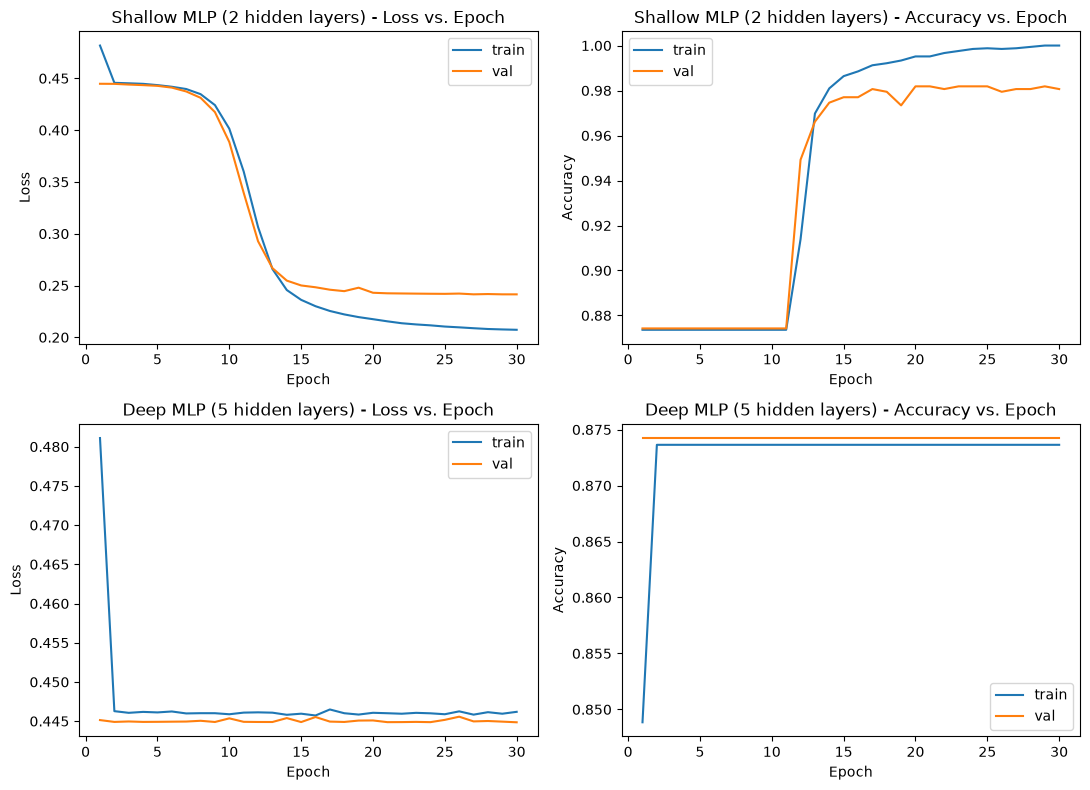

In [18]:
import matplotlib.pyplot as plt

def plot_history(history, title, ax_row):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    ax_row[0].plot(epochs_range, history["train_loss"], label="train")
    ax_row[0].plot(epochs_range, history["val_loss"], label="val")
    ax_row[0].set_title(f"{title} - Loss vs. Epoch")
    ax_row[0].set_xlabel("Epoch")
    ax_row[0].set_ylabel("Loss")
    ax_row[0].legend()

    ax_row[1].plot(epochs_range, history["train_acc"], label="train")
    ax_row[1].plot(epochs_range, history["val_acc"], label="val")
    ax_row[1].set_title(f"{title} - Accuracy vs. Epoch")
    ax_row[1].set_xlabel("Epoch")
    ax_row[1].set_ylabel("Accuracy")
    ax_row[1].legend()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_history(shallow_history, "Shallow MLP (2 hidden layers)", axes[0])
plot_history(deep_history, "Deep MLP (5 hidden layers)", axes[1])
fig.tight_layout()
plt.show()

## Shallow vs. deep: test-set comparison
Final evaluation on the held-out test set, touched for the first time here.
Precision/recall/F1 are reported alongside accuracy because, with only ~13%
spam, accuracy alone can hide a model (like our deep one) that just predicts
the majority class.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch).argmax(dim=1)
            all_preds.append(preds)
            all_targets.append(y_batch)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

shallow_test_metrics = evaluate(shallow_model, test_loader)
deep_test_metrics = evaluate(deep_model, test_loader)

comparison_df = pd.DataFrame([
    {"model": "Shallow MLP (2 hidden layers)", **shallow_test_metrics},
    {"model": "Deep MLP (5 hidden layers)", **deep_test_metrics},
])
comparison_df

,model,accuracy,precision,recall,f1
0,Shallow MLP (2 hidden layers),0.978723,0.950413,0.877863,0.912698
1,Deep MLP (5 hidden layers),0.873308,0.000000,0.000000,0.000000


## Summary

- **Best loss/optimizer (3x3 grid, shallow MLP):** cross-entropy with label
  smoothing + SGD with momentum (val_acc ≈ 0.977), though several combinations
  scored within a fraction of a percent of each other.
- **Best learning rate:** 0.01 — lower rates (0.001, 0.0001) were too small
  for SGD to escape the "always predict ham" baseline within 15 epochs.
- **Regularization strength used throughout:** weight_decay = 1e-4 (L2) on
  every optimizer.
- **Shallow vs. deep:** the shallow network trained successfully (97.9% test
  accuracy, 0.91 F1). The deep network, using the same settings, never learned
  to detect spam at all (0.87 accuracy, 0.0 precision/recall/F1 — it just
  predicted "ham" for every message). A 10x larger learning rate didn't fix
  it either. This points to an optimization difficulty specific to depth:
  without batch normalization or careful initialization, a plain 5-hidden-
  layer MLP trained with vanilla SGD can fail to propagate useful gradients
  back to its early layers. The hyperparameters tuned for a shallow network
  did not transfer to a deeper one — a concrete illustration of why "deeper"
  isn't automatically "better" without also adapting how the network is trained.